In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from scipy.signal import welch # We'll need this for power spectral density estimation eventually

# Allow for interactive plotting in Jupyter notebooks, comment out the line to turn this off. 
# The % sign is a Jupyter magic command that enables the use of widgets in the notebook.
# This requires installing the ipympl package, so if you get an error on this line, 
# you may need to install it first by running: pip install ipympl

%matplotlib widget 

# For interactive data point selection in plots, this library is useful.
import mplcursors 

# Add this line of code to each plot if you want cursors: 
# mplcursors.cursor(hover=False, multiple=True)  # Enable interactive cursor for data point selection, right-click to remove cursor

# Use this command to set the default font size for your plots.
sns.set_context("notebook")
# Options from smallest to largest: "paper", "notebook", "talk", "poster"

# Data Processing

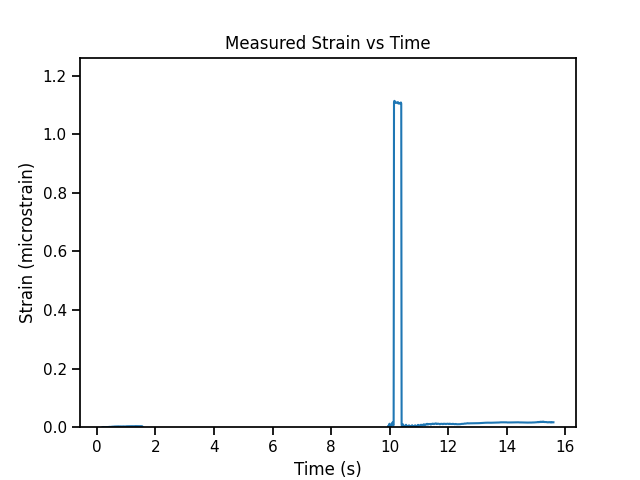

In [ ]:
hundodata = pd.read_csv("hundredgramsdata.csv") # Loading the dataset  
hundodata.head() #Display first few rows

Gain = 128
Vr = (hundodata['Vout']/5.06) / Gain  # Calculate the voltage output (Vr) from the raw strain data using the provided conversion factor and gain
hundodata['Vr'] = Vr  # Add the calculated Vr as a new column in the DataFrame

GF = 2.11  # Gauge factor for the strain gauge
baseline_region = hundodata[(hundodata['Times (us)']> 3e+06) & (hundodata['Times (us)']< 7e+06)]  # Define the baseline region
baseline = baseline_region['Vr'].mean()  # Calculate the mean voltage in the baseline region
New_Vr = hundodata['Vr'] - baseline  # Subtract the baseline from the Vr values to get the corrected voltage
hundodata['Strain'] = ((-4 * New_Vr) / (GF * (1 + 2 * New_Vr)))  # Calculate strain from voltage output and gauge factor

hundodata['Strain_micro'] = hundodata['Strain'] * 1e6  # Convert to microstrain

hundodata['Time (s)'] = hundodata['Times (us)'] * 1e-6  # Convert time from microseconds to seconds
hundodata['Strain_smooth'] = hundodata['Strain_micro'].rolling(window=20, center=True, min-period=1).mean()  # Apply a rolling mean with a smaller window size for clearer response

plt.figure()  # Create a new figure
sns.lineplot(x="Time (s)", y="Strain_smooth", data=hundodata)
plt.title("Measured Strain vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Strain (microstrain)")

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

Data Processing for 100 grams

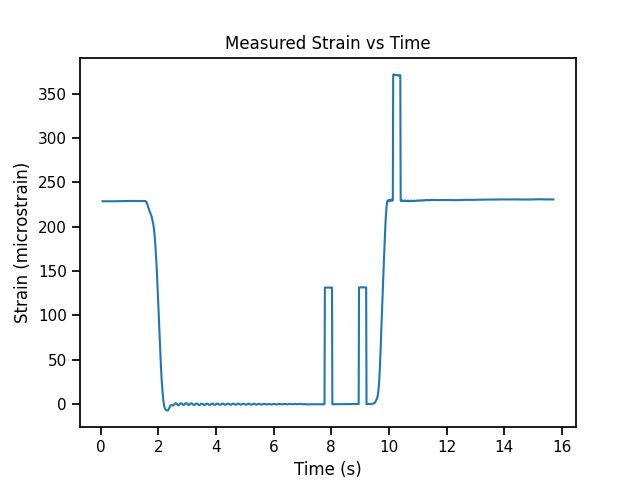

In [12]:
hdata = pd.read_csv("hundredgramsdata.csv")

# Convert raw ADC → voltage
hdata['Vout'] = hdata['strain (raw)'] * (5.06 / 16777215)

# Apply gain ONCE
Gain = 128
hdata['Vr'] = (hdata['Vout'] / 5.06) / Gain

# Baseline (choose flat region from your plot)
baseline_region = hdata[(hdata['Times (us)'] > 3e6) & (hdata['Times (us)'] < 7e6)]
baseline = baseline_region['Vr'].mean()

Vr_corrected = hdata['Vr'] - baseline

# Strain calculation
GF = 2.11
hdata['Strain'] = (-4 * Vr_corrected) / (GF * (1 + 2 * Vr_corrected))

# Convert to microstrain
hdata['Strain_micro'] = hdata['Strain'] * 1e6

# Time conversion
hdata['Time (s)'] = hdata['Times (us)'] * 1e-6

# Smoothing
hdata['Strain_smooth'] = hdata['Strain_micro'].rolling(
    window=20, center=True, min_periods=1
).mean()

# Plot
plt.figure()
sns.lineplot(x="Time (s)", y="Strain_smooth", data=hdata)
plt.title("Measured Strain vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Strain (microstrain)")

mplcursors.cursor(hover=False)
plt.show()

Data Processing for 50g

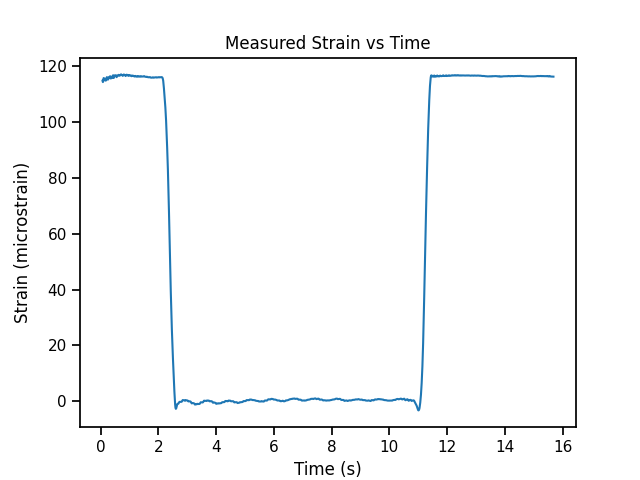

In [13]:
ffdata = pd.read_csv("fiftygramsdata.csv")

# Convert raw ADC → voltage
ffdata['Vout'] = ffdata['strain (raw)'] * (5.06 / 16777215)

# Apply gain ONCE
Gain = 128
ffdata['Vr'] = (ffdata['Vout'] / 5.06) / Gain

# Baseline (choose flat region from your plot)
baseline_region = ffdata[(ffdata['Times (us)'] > 3e6) & (ffdata['Times (us)'] < 7e6)]
baseline = baseline_region['Vr'].mean()

Vr_corrected = ffdata['Vr'] - baseline

# Strain calculation
GF = 2.11
ffdata['Strain'] = (-4 * Vr_corrected) / (GF * (1 + 2 * Vr_corrected))

# Convert to microstrain
ffdata['Strain_micro'] = ffdata['Strain'] * 1e6

# Time conversion
ffdata['Time (s)'] = ffdata['Times (us)'] * 1e-6

# Smoothing
ffdata['Strain_smooth'] = ffdata['Strain_micro'].rolling(
    window=20, center=True, min_periods=1
).mean()

# Plot
plt.figure()
sns.lineplot(x="Time (s)", y="Strain_smooth", data=ffdata)
plt.title("Measured Strain vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Strain (microstrain)")

mplcursors.cursor(hover=False)
plt.show()

Data Processing for 20g

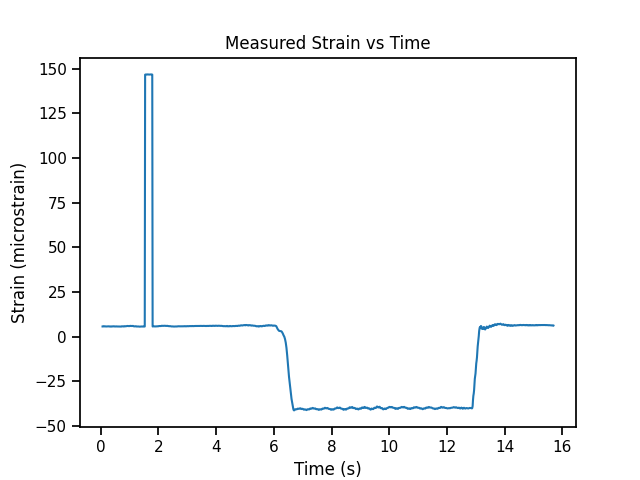

In [14]:
ttdata = pd.read_csv("twentygramsdata.csv")

# Convert raw ADC → voltage
ttdata['Vout'] = ttdata['strain (raw)'] * (5.06 / 16777215)

# Apply gain ONCE
Gain = 128
ttdata['Vr'] = (ttdata['Vout'] / 5.06) / Gain

# Baseline (choose flat region from your plot)
baseline_region = ttdata[(ttdata['Times (us)'] > 3e6) & (ttdata['Times (us)'] < 7e6)]
baseline = baseline_region['Vr'].mean()

Vr_corrected = ttdata['Vr'] - baseline

# Strain calculation
GF = 2.11
ttdata['Strain'] = (-4 * Vr_corrected) / (GF * (1 + 2 * Vr_corrected))

# Convert to microstrain
ttdata['Strain_micro'] = ttdata['Strain'] * 1e6

# Time conversion
ttdata['Time (s)'] = ttdata['Times (us)'] * 1e-6

# Smoothing
ttdata['Strain_smooth'] = ttdata['Strain_micro'].rolling(
    window=20, center=True, min_periods=1
).mean()

# Plot
plt.figure()
sns.lineplot(x="Time (s)", y="Strain_smooth", data=ttdata)
plt.title("Measured Strain vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Strain (microstrain)")

mplcursors.cursor(hover=False)
plt.show()

Data Processing for 10 grams

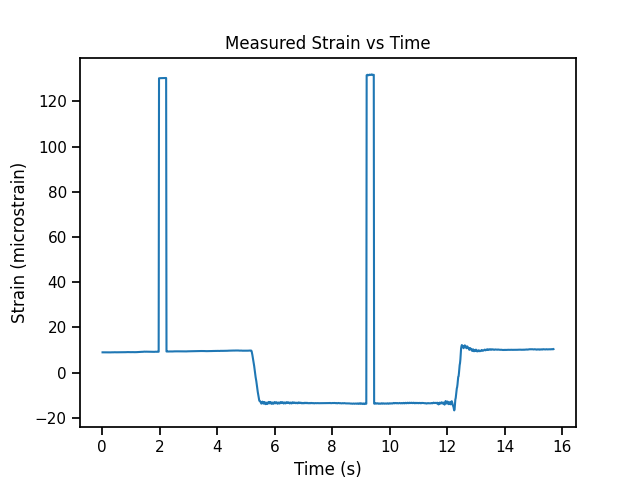

In [15]:
tdata = pd.read_csv("tengramsdata.csv")

# Convert raw ADC → voltage
tdata['Vout'] = tdata['strain (raw)'] * (5.06 / 16777215)

# Apply gain ONCE
Gain = 128
tdata['Vr'] = (tdata['Vout'] / 5.06) / Gain

# Baseline (choose flat region from your plot)
baseline_region = tdata[(tdata['Times (us)'] > 3e6) & (tdata['Times (us)'] < 7e6)]
baseline = baseline_region['Vr'].mean()

Vr_corrected = tdata['Vr'] - baseline

# Strain calculation
GF = 2.11
tdata['Strain'] = (-4 * Vr_corrected) / (GF * (1 + 2 * Vr_corrected))

# Convert to microstrain
tdata['Strain_micro'] = tdata['Strain'] * 1e6

# Time conversion
tdata['Time (s)'] = tdata['Times (us)'] * 1e-6

# Smoothing
tdata['Strain_smooth'] = tdata['Strain_micro'].rolling(
    window=20, center=True, min_periods=1
).mean()

# Plot
plt.figure()
sns.lineplot(x="Time (s)", y="Strain_smooth", data=tdata)
plt.title("Measured Strain vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Strain (microstrain)")

mplcursors.cursor(hover=False)
plt.show()

Data Processing for 5 grams

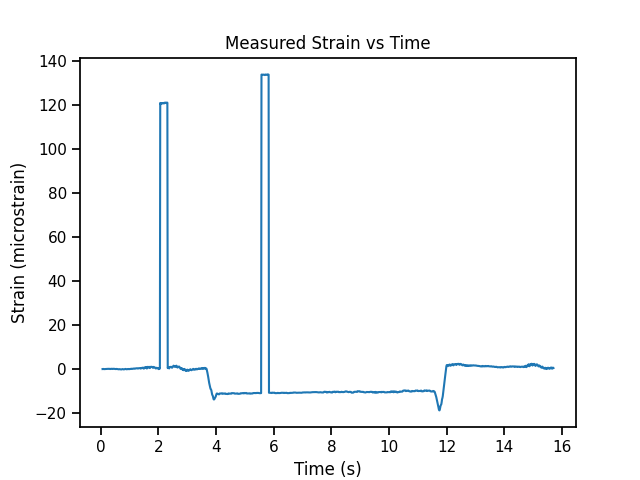

In [16]:
fdata = pd.read_csv("fivegramsdata.csv")

# Convert raw ADC → voltage
fdata['Vout'] = fdata['strain (raw)'] * (5.06 / 16777215)

# Apply gain ONCE
Gain = 128
fdata['Vr'] = (fdata['Vout'] / 5.06) / Gain

# Baseline (choose flat region from your plot)
baseline_region = fdata[(fdata['Times (us)'] > 3e6) & (fdata['Times (us)'] < 7e6)]
baseline = baseline_region['Vr'].mean()

Vr_corrected = fdata['Vr'] - baseline

# Strain calculation
GF = 2.11
fdata['Strain'] = (-4 * Vr_corrected) / (GF * (1 + 2 * Vr_corrected))

# Convert to microstrain
fdata['Strain_micro'] = fdata['Strain'] * 1e6

# Time conversion
fdata['Time (s)'] = fdata['Times (us)'] * 1e-6

# Smoothing
fdata['Strain_smooth'] = fdata['Strain_micro'].rolling(
    window=20, center=True, min_periods=1
).mean()

# Plot
plt.figure()
sns.lineplot(x="Time (s)", y="Strain_smooth", data=fdata)
plt.title("Measured Strain vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Strain (microstrain)")

mplcursors.cursor(hover=False)
plt.show()